# Sentimen Analisis Review Play Store APK Duolingo

Selamat datang dalam proyek Sentimen Analisi Review APK Play Store ini! Dalam era digital yang berkembang pesat ini, ulasan pengguna memiliki peran penting dalam membentuk persepsi terhadap aplikasi mobile. Dalam proyek ini, kita akan menjelajahi dunia analisis sentimen untuk memahami bagaimana orang merasakan dan mengungkapkan pendapat mereka tentang aplikasi di Google Play Store.

Analisis sentimen adalah salah satu cabang penting dalam pemrosesan bahasa alami yang memungkinkan kita untuk secara otomatis mengidentifikasi apakah ulasan pengguna cenderung positif atau
negatif. Dengan demikian, proyek ini akan membantu kita dalam memahami umpan balik pengguna dengan lebih baik, dan dapat digunakan untuk mengambil keputusan yang lebih baik dalam pengembangan dan perbaikan aplikasi.

Dalam perjalanan ini, kita akan menggali konsep-konsep penting dalam analisis sentimen, seperti pengolahan teks, ekstraksi fitur, dan penggunaan model machine learning untuk memprediksi sentimen ulasan. Kami akan menggunakan bahasa pemrograman Python dan beberapa pustaka populer seperti NLTK, scikit-learn, dan TensorFlow.

Tentunya, proyek ini akan memberi Anda wawasan yang berharga dalam analisis sentimen dan keterampilan pemrograman yang relevan. Mari kita mulai memahami bagaimana kita dapat mengungkap sentimen di balik ulasan pengguna di Play Store!

# IMPORT LIBRARY

In [182]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks


In [183]:
import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stop words) dalam berbagai bahasa.
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Loading Dataset

In [184]:
df = pd.read_csv("dataset_duolingo_review.csv")
#df = dataset.copy()

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = df.shape

In [185]:
# Menampilkan lima baris pertama dari DataFrame df
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,65c92763-c18a-4586-8236-42ac32e79235,Ayu Ika,https://play-lh.googleusercontent.com/a/ACg8ocJU7T7rx5vmjHTSrX2WN4yCX6uV9Ipx8CkcXk1pzwMOdvf4Qw=mo,"sangat bagusss! hanya saja terkadang ada kesalahan. terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran, tiba-tiba suara pelajaran terdengar, seperti ""す"" atau bunyi lain atau kosakata. aneh tapi itu selalu. dan juga, sering kali ketika berlian ku sudah terkumpul 1000-3000, terkadang baterai ku habis dan aku membeli baterai seharga 250-an (tidak tau aku lupa) namun malah berlian ku tersisa 11 atau pun 30 begitu saja, padahal tadinya banyak. tolong di pebaiki",4,1,6.74.5,2026-04-15 14:49:15,NaN,NaN,6.74.5
1,52914826-4cf2-4058-849d-bbdad7a4f424,Anindita Aretha,https://play-lh.googleusercontent.com/a-/ALV-UjXg9SsXSgKQ-B9qUBAtykZFhUSLsX7gI2UtDpQfwlJ2TD9sS9w,"Aplikasinya bagus banget buat belajar bahasa Inggris dan bahasa"" lain karena seru, tapi kadang ada bug pas aku udah ngerjain pelajarannya buat dapet xp malah layarnya jadi item dan xp nya ga bisa di klaim:( trus juga pas di liga, xp dari pelajaran yg dikerjain ga muncul dan itu aku udah di zona kenaikan, tapi di gambar liga nya tuh masih ada tanda ⬇ warna merah:(( Mohon diperbaiki bug nya.",5,4,6.74.4,2026-04-09 11:39:24,NaN,NaN,6.74.4
2,65cd368d-02a0-46ae-a7e4-8401e328f125,PiraaXtecu,https://play-lh.googleusercontent.com/a-/ALV-UjVsSzmhtJtktT17aH9ZJvnZXwNnMPukz_78yW0VM6qZmoDTgSQ,"Aplikasi Duolingo sangat bagus untuk belajar bahasa dengan cara yang seru dan tidak membosankan. Pembelajarannya dibuat seperti game, jadi bikin semangat belajar setiap hari. Banyak pilihan bahasa yang bisa dipelajari dan materinya cukup lengkap, mulai dari membaca, mendengar, hingga menulis. Tampilannya juga menarik dan mudah digunakan, cocok untuk pemula. Selain itu, fitur streak dan hadiah membuat pengguna lebih termotivasi untuk belajar secara rutin. Namun, terkadang ada iklan.",5,2,6.74.5,2026-04-12 22:58:56,NaN,NaN,6.74.5
3,5e775c54-b4af-4c39-8ac5-7182100a5f96,Fatihul Khoiri,https://play-lh.googleusercontent.com/a/ACg8ocLI8eQEaWmxuI_DAphU1HWhMgAhtHI4Yj5s1PtvDxpS6ds6sg=mo,"overall udah bagus , saya suka dari segi pembelajarannya , yg mana semakin kita meningkat tiap levelnya pasti ada cara belajar yg unik² lagi , jadi tidak bosan belajar . apalagi ada kompetisi nya , alhamdulillah saya sudah di liga obsidia , jujur semakin sulit juga karena saya tidak bayar premium jadi agak ketertinggalan . tapi ada 1 bug yg akhir² ini saya rasakan , setiap kali saya membayar energi dgn dm yg saya punya , dm nya selalu hangus padahal saya sama sekali tidak mendapat energi. plis",4,3,6.74.5,2026-04-11 08:19:24,NaN,NaN,6.74.5
4,d77ac4f3-319f-4a2a-ab55-151f2be60089,Dwi Regina putri,https://play-lh.googleusercontent.com/a/ACg8ocLZR_3BjAlU8jOz-7nSt43J_NDD4am9zZJTot0dawdARd40KA=mo,"Aplikasinya sangat bagus dan cocok untuk orang yang ingin belajar bahasa asing. Materinya menarik dan mudah dipahami. Namun, yang paling membuat aku kesal adalah pada bagian latihan berbicara, meskipun pengucapan aku udah benar dan sama seperti contoh, sering kali tetap dianggap salah. Hal itu cukup membuat aku kesal.... Semoga fitur pengenalan suaranya bisa diperbaiki lagi.",5,1,6.74.5,2026-04-13 13:16:24,NaN,NaN,6.74.5


In [186]:
# Menampilkan informasi tentang DataFrame df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewId              20000 non-null  object 
 1   userName              20000 non-null  object 
 2   userImage             20000 non-null  object 
 3   content               20000 non-null  object 
 4   score                 20000 non-null  int64  
 5   thumbsUpCount         20000 non-null  int64  
 6   reviewCreatedVersion  18743 non-null  object 
 7   at                    20000 non-null  object 
 8   replyContent          0 non-null      float64
 9   repliedAt             0 non-null      float64
 10  appVersion            18743 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 1.7+ MB


### DROPFITUR DATASET

Disini saya mengalami kendala dimana saat mengecek isnull(), terdapat banyak kolom yang memiliki value kosong yang mengakibatkan jika dropna() akan menghapus seluruh dataframe. Jadi solusi yang saya lakukan adalah langsung dropfitur yang tidak dipakai sehingga dapat lanjut proses pengecekan null terutama pada kolom content sebagai FOKUS utama.

In [187]:
#mengecek apakah masih ada null
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,1257
at,0
replyContent,20000
repliedAt,20000


In [188]:
#Pertama drop dulu fitur yang tidak diperlukan dikarenakan beberapa tidak ada data
df = df[["userName","score","thumbsUpCount","content","at"]]
df.head()

,userName,score,thumbsUpCount,content,at
0,Ayu Ika,4,1,"sangat bagusss! hanya saja terkadang ada kesalahan. terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran, tiba-tiba suara pelajaran terdengar, seperti ""す"" atau bunyi lain atau kosakata. aneh tapi itu selalu. dan juga, sering kali ketika berlian ku sudah terkumpul 1000-3000, terkadang baterai ku habis dan aku membeli baterai seharga 250-an (tidak tau aku lupa) namun malah berlian ku tersisa 11 atau pun 30 begitu saja, padahal tadinya banyak. tolong di pebaiki",2026-04-15 14:49:15
1,Anindita Aretha,5,4,"Aplikasinya bagus banget buat belajar bahasa Inggris dan bahasa"" lain karena seru, tapi kadang ada bug pas aku udah ngerjain pelajarannya buat dapet xp malah layarnya jadi item dan xp nya ga bisa di klaim:( trus juga pas di liga, xp dari pelajaran yg dikerjain ga muncul dan itu aku udah di zona kenaikan, tapi di gambar liga nya tuh masih ada tanda ⬇ warna merah:(( Mohon diperbaiki bug nya.",2026-04-09 11:39:24
2,PiraaXtecu,5,2,"Aplikasi Duolingo sangat bagus untuk belajar bahasa dengan cara yang seru dan tidak membosankan. Pembelajarannya dibuat seperti game, jadi bikin semangat belajar setiap hari. Banyak pilihan bahasa yang bisa dipelajari dan materinya cukup lengkap, mulai dari membaca, mendengar, hingga menulis. Tampilannya juga menarik dan mudah digunakan, cocok untuk pemula. Selain itu, fitur streak dan hadiah membuat pengguna lebih termotivasi untuk belajar secara rutin. Namun, terkadang ada iklan.",2026-04-12 22:58:56
3,Fatihul Khoiri,4,3,"overall udah bagus , saya suka dari segi pembelajarannya , yg mana semakin kita meningkat tiap levelnya pasti ada cara belajar yg unik² lagi , jadi tidak bosan belajar . apalagi ada kompetisi nya , alhamdulillah saya sudah di liga obsidia , jujur semakin sulit juga karena saya tidak bayar premium jadi agak ketertinggalan . tapi ada 1 bug yg akhir² ini saya rasakan , setiap kali saya membayar energi dgn dm yg saya punya , dm nya selalu hangus padahal saya sama sekali tidak mendapat energi. plis",2026-04-11 08:19:24
4,Dwi Regina putri,5,1,"Aplikasinya sangat bagus dan cocok untuk orang yang ingin belajar bahasa asing. Materinya menarik dan mudah dipahami. Namun, yang paling membuat aku kesal adalah pada bagian latihan berbicara, meskipun pengucapan aku udah benar dan sama seperti contoh, sering kali tetap dianggap salah. Hal itu cukup membuat aku kesal.... Semoga fitur pengenalan suaranya bisa diperbaiki lagi.",2026-04-13 13:16:24


In [189]:
#mengecek apakah masih ada null
df.isnull().sum()

,0
userName,0
score,0
thumbsUpCount,0
content,0
at,0


In [190]:
# Membuat DataFrame baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari df
clean_df = df.dropna()

In [191]:
#mengecek ada data duplikat df
df.duplicated().sum()

np.int64(0)

In [192]:
#Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

##Preprocessing

Berikut adalah beberapa fungsi yang digunakan untuk membersihkan dan memproses teks. Inilah penjelasan singkat tentang masing-masing fungsi:

1. `cleaningText(text)`: Fungsi ini digunakan untuk membersihkan teks dengan beberapa langkah, seperti menghapus mention, hashtag, RT (retweet), tautan (link), angka, dan tanda baca. Selain itu, itu juga menggantikan karakter newline dengan spasi dan menghilangkan spasi ekstra di awal dan akhir teks.

2. `casefoldingText(text)`: Fungsi ini mengonversi semua karakter dalam teks menjadi huruf kecil (lowercase), sehingga teks menjadi lebih seragam.

3. `tokenizingText(text)`: Fungsi ini digunakan untuk membagi teks menjadi daftar kata atau token. Ini berguna untuk mengurai teks menjadi komponen-komponen dasar.

4. `filteringText(text)`: Fungsi ini digunakan untuk menghapus kata-kata berhenti (stopwords) dalam teks. Anda telah memperbarui daftar kata-kata berhenti dengan beberapa kata tambahan.

5. `stemmingText(text)`: Fungsi ini menerapkan stemming pada teks, yaitu mengurangi kata-kata menjadi bentuk dasarnya. Anda menggunakan pustaka Sastrawi untuk melakukan stemming dalam bahasa Indonesia.

6. `toSentence(list_words)`: Fungsi ini digunakan untuk menggabungkan daftar kata-kata menjadi sebuah kalimat.

Anda dapat menggunakan fungsi-fungsi ini dalam proyek Anda untuk membersihkan, memproses, dan mempersiapkan teks sebelum melakukan analisis sentimen. Pastikan untuk memanggil fungsi-fungsi ini dengan benar sesuai dengan tahap pemrosesan teks yang Anda inginkan.

In [193]:
### Case Folding
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # remove hashtag
    text = re.sub(r'RT[\s]', '', text) # remove RT
    text = re.sub(r"http\S+", '', text) # remove link
    text = re.sub(r'[0-9]+', '', text) # remove numbers
    text = re.sub(r'[^\w\s]', '', text) # remove numbers

    text = text.replace("\n"," ")# replace new line into space
    text = text.translate(str.maketrans('','',string.punctuation))
    def remove_punctuation(text_p):
        punctuation_set = set(string.punctuation)

        text_p = ''.join(char for char in text_p if char not in punctuation_set)
        return text_p

    remove_punctuation(text)
    text = text.strip(' ')
    return text

def clearEmoji(text): # Untuk menghapus emoji
    return text.encode('ascii', 'ignore').decode('ascii')

def replaceTOM(text): # menedit kata duplikat seperti cooontoh menjadi contoh
    return re.sub(r'(.)\1{2,}',r'\1\1', text)

def casefoldingText(text): # Converting all the characters in a text into lower case
    text = text.lower()
    return text

def tokenizingText(text):# Tokenizing or splitting a string, text into a list of tokens
    text = word_tokenize(text)
    return text

listStopwords = set(stopwords.words('indonesian'))
listStopwords1 = set(stopwords.words('english'))
def filteringText(text): # Remove stopwors in a text
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

#membuat objekstemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stemmingText(text): # Reducing a word to its word stem that affixes to suffixes and prefixes or to the roots of words
    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Convert list of words into sentence
    sentence = ' '.join(word for word in list_words)
    return sentence

In [194]:
#https://www.kaggle.com/datasets/ahmadseloabadi/slangwords-and-stopwords-bahasa-indonesia?resource=download&select=slangwords.txt
slangwords = {"@" : "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text


Kamus slang atau daftar kata-kata slang yang Anda berikan adalah kumpulan kata-kata slang bahasa Indonesia beserta terjemahan atau artinya dalam bahasa formal. Fungsi dari kamus slang seperti ini adalah:

1. **Mengartikan Slang:** Kamus slang membantu orang yang mungkin tidak familiar dengan bahasa slang atau ekspresi yang digunakan di kalangan tertentu untuk memahami makna kata-kata tersebut.

2. **Komunikasi Informal:** Slang sering digunakan dalam percakapan informal atau di media sosial. Kamus slang membantu orang untuk berkomunikasi dengan gaya yang lebih santai dan sesuai dengan konteksnya.

3. **Pemahaman Budaya Pop:** Slang sering kali terkait dengan budaya pop dan dapat mencerminkan tren dan perubahan dalam bahasa. Kamus slang memungkinkan orang untuk mengikuti dan memahami bahasa dalam konteks budaya ini.

4. **Penggunaan Sastra dan Penulisan:** Penulis atau pembicara mungkin ingin menggunakan slang dalam tulisannya untuk menciptakan efek tertentu atau mengekspresikan karakter atau setting yang lebih realistis. Kamus slang dapat membantu mereka memilih kata-kata dengan tepat.

5. **Hiburan dan Curiositas:** Beberapa orang mungkin tertarik untuk mempelajari bahasa slang hanya untuk hiburan atau karena rasa ingin tahu terhadap variasi bahasa dan ungkapan dalam bahasa sehari-hari.

Ingatlah bahwa penggunaan slang harus disesuaikan dengan konteks dan audiens. Slang cenderung lebih cocok untuk percakapan santai dengan teman-teman atau di lingkungan yang informal. Dalam situasi formal, penggunaan bahasa formal lebih sesuai.

In [195]:
clean_df.head()

,userName,score,thumbsUpCount,content,at
0,Ayu Ika,4,1,"sangat bagusss! hanya saja terkadang ada kesalahan. terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran, tiba-tiba suara pelajaran terdengar, seperti ""す"" atau bunyi lain atau kosakata. aneh tapi itu selalu. dan juga, sering kali ketika berlian ku sudah terkumpul 1000-3000, terkadang baterai ku habis dan aku membeli baterai seharga 250-an (tidak tau aku lupa) namun malah berlian ku tersisa 11 atau pun 30 begitu saja, padahal tadinya banyak. tolong di pebaiki",2026-04-15 14:49:15
1,Anindita Aretha,5,4,"Aplikasinya bagus banget buat belajar bahasa Inggris dan bahasa"" lain karena seru, tapi kadang ada bug pas aku udah ngerjain pelajarannya buat dapet xp malah layarnya jadi item dan xp nya ga bisa di klaim:( trus juga pas di liga, xp dari pelajaran yg dikerjain ga muncul dan itu aku udah di zona kenaikan, tapi di gambar liga nya tuh masih ada tanda ⬇ warna merah:(( Mohon diperbaiki bug nya.",2026-04-09 11:39:24
2,PiraaXtecu,5,2,"Aplikasi Duolingo sangat bagus untuk belajar bahasa dengan cara yang seru dan tidak membosankan. Pembelajarannya dibuat seperti game, jadi bikin semangat belajar setiap hari. Banyak pilihan bahasa yang bisa dipelajari dan materinya cukup lengkap, mulai dari membaca, mendengar, hingga menulis. Tampilannya juga menarik dan mudah digunakan, cocok untuk pemula. Selain itu, fitur streak dan hadiah membuat pengguna lebih termotivasi untuk belajar secara rutin. Namun, terkadang ada iklan.",2026-04-12 22:58:56
3,Fatihul Khoiri,4,3,"overall udah bagus , saya suka dari segi pembelajarannya , yg mana semakin kita meningkat tiap levelnya pasti ada cara belajar yg unik² lagi , jadi tidak bosan belajar . apalagi ada kompetisi nya , alhamdulillah saya sudah di liga obsidia , jujur semakin sulit juga karena saya tidak bayar premium jadi agak ketertinggalan . tapi ada 1 bug yg akhir² ini saya rasakan , setiap kali saya membayar energi dgn dm yg saya punya , dm nya selalu hangus padahal saya sama sekali tidak mendapat energi. plis",2026-04-11 08:19:24
4,Dwi Regina putri,5,1,"Aplikasinya sangat bagus dan cocok untuk orang yang ingin belajar bahasa asing. Materinya menarik dan mudah dipahami. Namun, yang paling membuat aku kesal adalah pada bagian latihan berbicara, meskipun pengucapan aku udah benar dan sama seperti contoh, sering kali tetap dianggap salah. Hal itu cukup membuat aku kesal.... Semoga fitur pengenalan suaranya bisa diperbaiki lagi.",2026-04-13 13:16:24


In [196]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

#emoji cleanning
clean_df["clearemoji"] = clean_df["text_clean"].apply(clearEmoji)

#TOM
clean_df["replaceTOM"] = clean_df["clearemoji"].apply(replaceTOM)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['replaceTOM'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [197]:
clean_df.head()

,userName,score,thumbsUpCount,content,at,text_clean,clearemoji,replaceTOM,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,Ayu Ika,4,1,"sangat bagusss! hanya saja terkadang ada kesalahan. terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran, tiba-tiba suara pelajaran terdengar, seperti ""す"" atau bunyi lain atau kosakata. aneh tapi itu selalu. dan juga, sering kali ketika berlian ku sudah terkumpul 1000-3000, terkadang baterai ku habis dan aku membeli baterai seharga 250-an (tidak tau aku lupa) namun malah berlian ku tersisa 11 atau pun 30 begitu saja, padahal tadinya banyak. tolong di pebaiki",2026-04-15 14:49:15,sangat bagusss hanya saja terkadang ada kesalahan terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran tibatiba suara pelajaran terdengar seperti す atau bunyi lain atau kosakata aneh tapi itu selalu dan juga sering kali ketika berlian ku sudah terkumpul terkadang baterai ku habis dan aku membeli baterai seharga an tidak tau aku lupa namun malah berlian ku tersisa atau pun begitu saja padahal tadinya banyak tolong di pebaiki,sangat bagusss hanya saja terkadang ada kesalahan terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran tibatiba suara pelajaran terdengar seperti atau bunyi lain atau kosakata aneh tapi itu selalu dan juga sering kali ketika berlian ku sudah terkumpul terkadang baterai ku habis dan aku membeli baterai seharga an tidak tau aku lupa namun malah berlian ku tersisa atau pun begitu saja padahal tadinya banyak tolong di pebaiki,sangat baguss hanya saja terkadang ada kesalahan terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran tibatiba suara pelajaran terdengar seperti atau bunyi lain atau kosakata aneh tapi itu selalu dan juga sering kali ketika berlian ku sudah terkumpul terkadang baterai ku habis dan aku membeli baterai seharga an tidak tau aku lupa namun malah berlian ku tersisa atau pun begitu saja padahal tadinya banyak tolong di pebaiki,sangat baguss hanya saja terkadang ada kesalahan terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran tibatiba suara pelajaran terdengar seperti atau bunyi lain atau kosakata aneh tapi itu selalu dan juga sering kali ketika berlian ku sudah terkumpul terkadang baterai ku habis dan aku membeli baterai seharga an tidak tau aku lupa namun malah berlian ku tersisa atau pun begitu saja padahal tadinya banyak tolong di pebaiki,sangat baguss hanya saja terkadang ada kesalahan terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran tibatiba suara pelajaran terdengar seperti atau bunyi lain atau kosakata aneh tapi itu selalu dan juga sering kali ketika berlian ku sudah terkumpul terkadang baterai ku habis dan aku membeli baterai seharga an tidak tahu aku lupa namun bahkan berlian ku tersisa atau pun begitu saja padahal tadinya banyak tolong di pebaiki,"[sangat, baguss, hanya, saja, terkadang, ada, kesalahan, terkadang, ketika, saya, tidak, memakai, aplikasi, atau, tidak, sedang, mengikuti, quis, pembelajaran, tibatiba, suara, pelajaran, terdengar, seperti, atau, bunyi, lain, atau, kosakata, aneh, tapi, itu, selalu, dan, juga, sering, kali, ketika, berlian, ku, sudah, terkumpul, terkadang, baterai, ku, habis, dan, aku, membeli, baterai, seharga, an, tidak, tahu, aku, lupa, namun, bahkan, berlian, ku, tersisa, atau, pun, begitu, saja, padahal, tadinya, banyak, tolong, di, pebaiki]","[baguss, terkadang, kesalahan, terkadang, memakai, aplikasi, mengikuti, quis, pembelajaran, tibatiba, suara, pelajaran, terdengar, bunyi, kosakata, aneh, kali, berlian, terkumpul, terkadang, baterai, habis, membeli, baterai, seharga, lupa, berlian, tersisa, tolong, pebaiki]",baguss terkadang kesalahan terkadang memakai aplikasi mengikuti quis pembelajaran tibatiba suara pelajaran terdengar bunyi kosakata aneh kali berlian terkumpul terkadan

In [198]:
clean_df.describe()

,score,thumbsUpCount
count,20000.000000,20000.000000
mean,4.545650,7.268500
std,0.986998,53.896473
min,1.000000,0.000000
25%,5.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,1.000000
max,5.000000,2204.000000


##Pelabelan

In [199]:
import csv
import requests
from io import StringIO

# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya ke dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [200]:
# Function to determine sentiment polarity of tweets
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score >= 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif

    # else:
    #     polarity = 'neutral'
    # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [201]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    10824
positive     9176
Name: count, dtype: int64


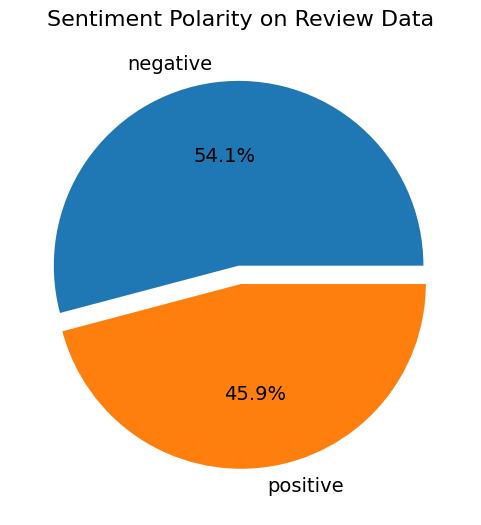

In [202]:
import matplotlib.pyplot as plt

# Membuat objek gambar dan sumbu dengan ukuran (6, 6) inci.
fig, ax = plt.subplots(figsize=(6, 6))

# Mengambil jumlah data polaritas sentimen dari DataFrame 'clean_df' dan menyimpannya dalam list 'sizes'.
sizes = [count for count in clean_df['polarity'].value_counts()]

# Mengambil label atau kategori sentimen dari DataFrame 'clean_df' dan menyimpannya dalam list 'labels'.
labels = list(clean_df['polarity'].value_counts().index)

# Menentukan seberapa jauh potongan dari pie chart akan ditarik (0.1 artinya potongan pertama akan sedikit terpisah).
explode = (0.1, 0)

# Membuat pie chart dengan data 'sizes', 'labels', dan 'explode' yang telah ditentukan.
# Autopct digunakan untuk menampilkan persentase di dalam setiap potongan pie.
# Textprops digunakan untuk mengatur ukuran font teks dalam pie chart.
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})

# Menetapkan judul untuk pie chart dengan ukuran font dan jarak (padding) tertentu.
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

# Menampilkan pie chart.
plt.show()

Diliat dari diagram bisa diliat bahwa data sedikit imbalance pada negative tapi masih dapat diwajarkan karena tidak melebihi 60 %

In [203]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'positive_tweets' yang hanya berisi tweet dengan polaritas positif.
positive_tweets = clean_df[clean_df['polarity'] == 'positive']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'positive_tweets'.
positive_tweets = positive_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'positive_tweets' berdasarkan 'polarity_score' secara menurun.
positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False)

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
positive_tweets = positive_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
positive_tweets.index += 1

In [204]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 3000 karakter.
pd.set_option('display.max_colwidth', 3000)

# Membuat DataFrame baru 'negative_tweets' yang hanya berisi tweet dengan polaritas negatif.
negative_tweets = clean_df[clean_df['polarity'] == 'negative']

# Memilih hanya kolom-kolom tertentu dari DataFrame 'negative_tweets'.
negative_tweets = negative_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

# Mengurutkan DataFrame 'negative_tweets' berdasarkan 'polarity_score' secara menaik (ascending).
negative_tweets = negative_tweets.sort_values(by='polarity_score', ascending=True)

# Memilih 10 baris pertama dari DataFrame yang sudah diurutkan.
negative_tweets = negative_tweets[0:10]

# Mengatur ulang indeks DataFrame agar dimulai dari 0.
negative_tweets = negative_tweets.reset_index(drop=True)

# Menambahkan 1 ke semua indeks DataFrame.
negative_tweets.index += 1

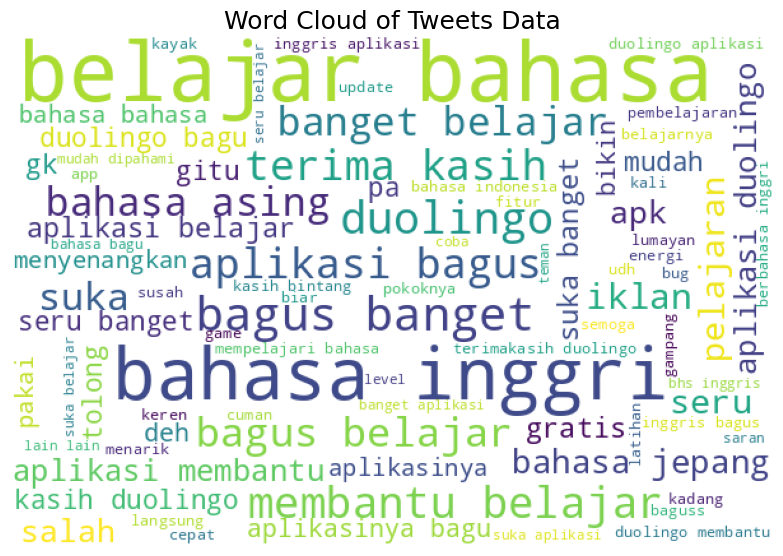

In [205]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'clean_df'.
for tweet in clean_df['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

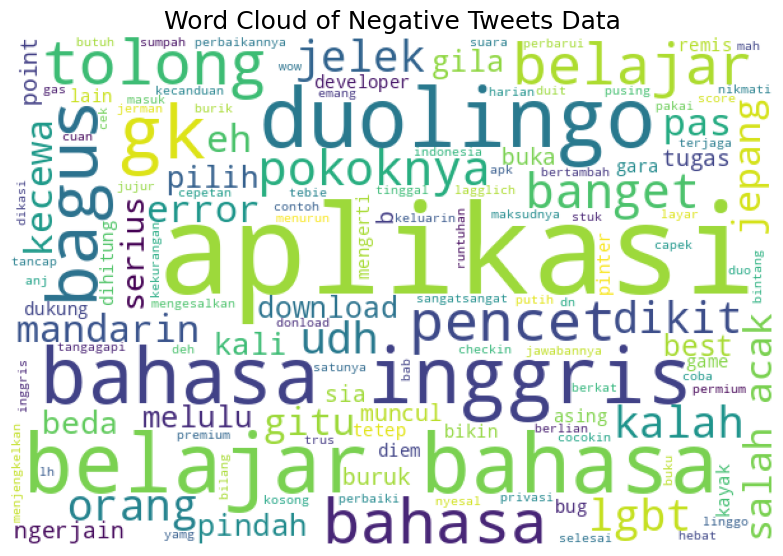

In [206]:
# Membuat string kosong 'list_words' yang akan digunakan untuk mengumpulkan semua kata dari teks yang sudah dibersihkan dalam tweet negatif.
list_words = ''

# Iterasi melalui setiap tweet dalam kolom 'text_stopword' dari DataFrame 'negative_tweets'.
for tweet in negative_tweets['text_stopword']:
    # Iterasi melalui setiap kata dalam tweet.
    for word in tweet:
        # Menambahkan kata ke dalam 'list_words'.
        list_words += ' ' + (word)

# Membuat objek WordCloud dengan parameter tertentu.
wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

# Membuat gambar dan sumbu untuk menampilkan word cloud.
fig, ax = plt.subplots(figsize=(8, 6))

# Menetapkan judul untuk word cloud.
ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)

# Menonaktifkan grid pada sumbu.
ax.grid(False)

# Menampilkan word cloud dalam gambar.
ax.imshow((wordcloud))

# Mengatur layout gambar.
fig.tight_layout(pad=0)

# Menyembunyikan sumbu.
ax.axis('off')

# Menampilkan word cloud.
plt.show()

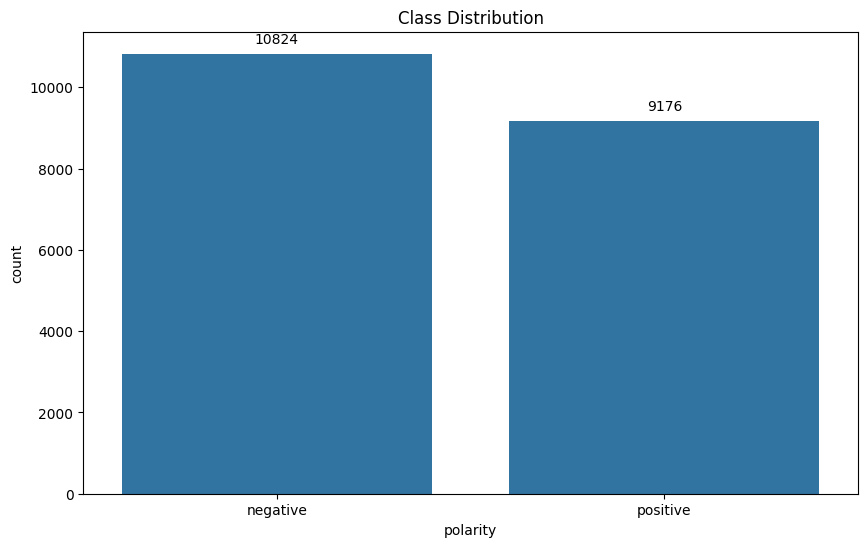

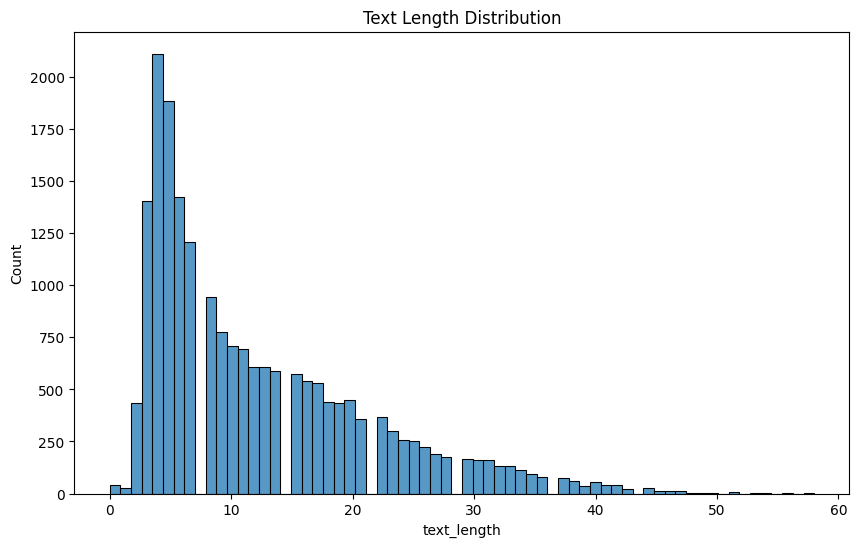

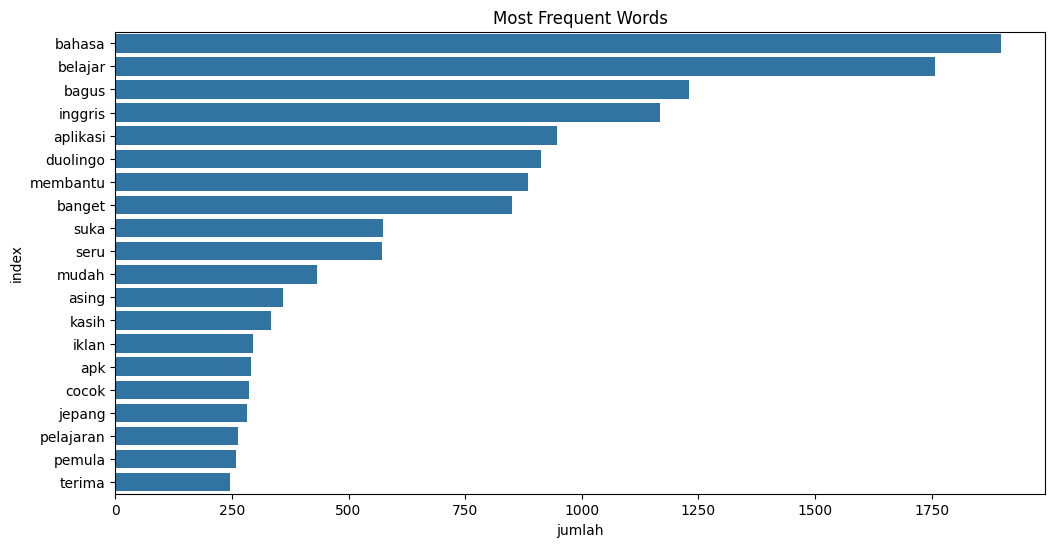

In [207]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Set the figure size
plt.figure(figsize=(10, 6))

# Check class distribution
class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

# Add counts above the bars on the plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# Set the figure size
plt.figure(figsize=(10, 6))

# Visualize text length distribution
clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

# Set the figure size
plt.figure(figsize=(12, 6))

# Visualize most frequent words
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

In [208]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score

## **Data Splitting**

In [209]:
clean_df.head(2)

,userName,score,thumbsUpCount,content,at,text_clean,clearemoji,replaceTOM,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,text_length
0,Ayu Ika,4,1,"sangat bagusss! hanya saja terkadang ada kesalahan. terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran, tiba-tiba suara pelajaran terdengar, seperti ""す"" atau bunyi lain atau kosakata. aneh tapi itu selalu. dan juga, sering kali ketika berlian ku sudah terkumpul 1000-3000, terkadang baterai ku habis dan aku membeli baterai seharga 250-an (tidak tau aku lupa) namun malah berlian ku tersisa 11 atau pun 30 begitu saja, padahal tadinya banyak. tolong di pebaiki",2026-04-15 14:49:15,sangat bagusss hanya saja terkadang ada kesalahan terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran tibatiba suara pelajaran terdengar seperti す atau bunyi lain atau kosakata aneh tapi itu selalu dan juga sering kali ketika berlian ku sudah terkumpul terkadang baterai ku habis dan aku membeli baterai seharga an tidak tau aku lupa namun malah berlian ku tersisa atau pun begitu saja padahal tadinya banyak tolong di pebaiki,sangat bagusss hanya saja terkadang ada kesalahan terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran tibatiba suara pelajaran terdengar seperti atau bunyi lain atau kosakata aneh tapi itu selalu dan juga sering kali ketika berlian ku sudah terkumpul terkadang baterai ku habis dan aku membeli baterai seharga an tidak tau aku lupa namun malah berlian ku tersisa atau pun begitu saja padahal tadinya banyak tolong di pebaiki,sangat baguss hanya saja terkadang ada kesalahan terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran tibatiba suara pelajaran terdengar seperti atau bunyi lain atau kosakata aneh tapi itu selalu dan juga sering kali ketika berlian ku sudah terkumpul terkadang baterai ku habis dan aku membeli baterai seharga an tidak tau aku lupa namun malah berlian ku tersisa atau pun begitu saja padahal tadinya banyak tolong di pebaiki,sangat baguss hanya saja terkadang ada kesalahan terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran tibatiba suara pelajaran terdengar seperti atau bunyi lain atau kosakata aneh tapi itu selalu dan juga sering kali ketika berlian ku sudah terkumpul terkadang baterai ku habis dan aku membeli baterai seharga an tidak tau aku lupa namun malah berlian ku tersisa atau pun begitu saja padahal tadinya banyak tolong di pebaiki,sangat baguss hanya saja terkadang ada kesalahan terkadang ketika saya tidak memakai aplikasi atau tidak sedang mengikuti quis pembelajaran tibatiba suara pelajaran terdengar seperti atau bunyi lain atau kosakata aneh tapi itu selalu dan juga sering kali ketika berlian ku sudah terkumpul terkadang baterai ku habis dan aku membeli baterai seharga an tidak tahu aku lupa namun bahkan berlian ku tersisa atau pun begitu saja padahal tadinya banyak tolong di pebaiki,"[sangat, baguss, hanya, saja, terkadang, ada, kesalahan, terkadang, ketika, saya, tidak, memakai, aplikasi, atau, tidak, sedang, mengikuti, quis, pembelajaran, tibatiba, suara, pelajaran, terdengar, seperti, atau, bunyi, lain, atau, kosakata, aneh, tapi, itu, selalu, dan, juga, sering, kali, ketika, berlian, ku, sudah, terkumpul, terkadang, baterai, ku, habis, dan, aku, membeli, baterai, seharga, an, tidak, tahu, aku, lupa, namun, bahkan, berlian, ku, tersisa, atau, pun, begitu, saja, padahal, tadinya, banyak, tolong, di, pebaiki]","[baguss, terkadang, kesalahan, terkadang, memakai, aplikasi, mengikuti, quis, pembelajaran, tibatiba, suara, pelajaran, terdengar, bunyi, kosakata, aneh, kali, berlian, terkumpul, terkadang, baterai, habis, membeli, baterai, seharga, lupa, berlian, tersisa, tolong, pebaiki]",baguss terkadang kesalahan terkadang memakai aplikasi mengikuti quis pembelajaran tibatiba suara pelajaran terdengar bunyi kosakata 

In [210]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']

In [211]:
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [212]:
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur
features_df

,anak,animasi,apapun,apk,aplikasi,aplikasinya,app,arab,asik,asing,...,thank,tolong,trus,tuh,uang,udh,ulang,update,wajib,xp
0,0.0,0.000000,0.0,0.000000,0.151274,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.240544,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.000000,0.0,0.000000,0.000000,0.142359,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.217868,0.197844,0.0,0.0,0.0,0.0,0.0,0.632865
2,0.0,0.000000,0.0,0.000000,0.120945,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.205302,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.000000,0.0,0.000000,0.000000,0.227145,0.0,0.0,0.0,0.228086,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.0,0.000000,0.0,0.000000,0.568214,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
19996,0.0,0.420953,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
19997,0.0,0.000000,0.0,0.510736,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
19998,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.285070,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000


In [213]:
#Ekstraksi fitur dengan WOrd2Vec
!pip install gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

w2v_model = Word2Vec(
    sentences=clean_df["text_akhir"],
    vector_size=100,
    window=5,
    min_count=2
)

In [214]:
def sentence_vector(tokens):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)


In [215]:
clean_df["w2v"] = clean_df["text_akhir"].apply(sentence_vector)
X_w2v = np.vstack(clean_df["w2v"])

### UNTUK LSTM

In [216]:
from sklearn.preprocessing import LabelEncoder

#Lakukan labeling encoder khusus lstm
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [217]:
from tensorflow.keras.preprocessing.text import Tokenizer

#Melakukan tokenisasi dataset
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)

In [218]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

#padding sentences max 51
#saya mendapatkan 51 dimana diliat dari dataset max length sentence menggunakan clean_df.describe()
max_len = 51

X_pad = pad_sequences(sequences, maxlen=max_len, padding='post')

In [219]:
# Bagi data menjadi data latih dan data uji
# Saya membagi dataset menjadi 3 train_test dataset untuk masing-masing model
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_w2v, y, test_size=0.3, random_state=42)

## **LSTM**

In [220]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    LSTM(64),
    Dense(1, activation='sigmoid')  # binary
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [221]:
from tensorflow.keras.callbacks import EarlyStopping

early_stoping = EarlyStopping(
    monitor='val_loss',        # penilaian Metrik val_loss
    patience=3,                # epoch pelatihan yang akan dilakukan
    min_delta=0.001,
    restore_best_weights=True  # kembalikan model ke kondisi acuracy tertinggi
)
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks = [early_stoping] # menggunakan callback early_stop
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 70ms/step - accuracy: 0.6098 - loss: 0.6574 - val_accuracy: 0.6560 - val_loss: 0.6364
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.6735 - loss: 0.6230 - val_accuracy: 0.6670 - val_loss: 0.6318
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.6887 - loss: 0.6147 - val_accuracy: 0.6722 - val_loss: 0.6282
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.6864 - loss: 0.6197 - val_accuracy: 0.6917 - val_loss: 0.6155
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.6982 - loss: 0.6123 - val_accuracy: 0.6917 - val_loss: 0.6155
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.7003 - loss: 0.6107 - val_accuracy: 0.6933 - val_loss: 0.6170
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.7061 - loss: 0.6062 - val_accuracy: 0.6948 - val_loss: 0.6158


In [222]:
loss, accuracy_test_LSTM = model.evaluate(X_test, y_test)

print("Accuracy Test LSTM:", accuracy_test_LSTM)

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6917 - loss: 0.6155
Accuracy Test LSTM: 0.6917499899864197


## **Pemodelan Naive Bayes**

In [223]:
from sklearn.naive_bayes import BernoulliNB , MultinomialNB

# Membuat objek model Naive Bayes (Bernoulli Naive Bayes)
naive_bayes = BernoulliNB()

# Melatih model Naive Bayes pada data pelatihan
naive_bayes.fit(X_train1.toarray(), y_train1)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_nb = naive_bayes.predict(X_train1.toarray())
y_pred_test_nb = naive_bayes.predict(X_test1.toarray())

# Evaluasi akurasi model Naive Bayes
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train1)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test1)

# Menampilkan akurasi
print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.7991875
Naive Bayes - accuracy_test: 0.7795


## **Random Forest**

In [224]:
from sklearn.ensemble import RandomForestClassifier

# Membuat objek model Random Forest
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)

# Melatih model Random Forest pada data pelatihan
random_forest.fit(X_train2, y_train2)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_rf = random_forest.predict(X_train2)
y_pred_test_rf = random_forest.predict(X_test2)

# Evaluasi akurasi model Random Forest
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train2)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test2)

# Menampilkan akurasi
print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.8606428571428572
Random Forest - accuracy_test: 0.6916666666666667


## **Logistic Regression**

In [225]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
logistic_regression = LogisticRegression(class_weight='balanced')

# Melatih model Logistic Regression pada data pelatihan
logistic_regression.fit(X_train1.toarray(), y_train1)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train1.toarray())
y_pred_test_lr = logistic_regression.predict(X_test1.toarray())

# Evaluasi akurasi model Logistic Regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train1)

# Evaluasi akurasi model Logistic Regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test1)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.8835625
Logistic Regression - accuracy_test: 0.8695


# **SVM**

In [226]:
from sklearn.svm import SVC

svm = SVC(
    C = 1,
    kernel = 'rbf',
    gamma = 'scale',
    class_weight= 'balanced',
)

svm.fit(X_train1, y_train1)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_svm = svm.predict(X_train1)
y_pred_test_svm = svm.predict(X_test1)

# Evaluasi akurasi model Decision Tree
accuracy_train_svm = accuracy_score(y_pred_train_svm, y_train1)
accuracy_test_svm = accuracy_score(y_pred_test_svm, y_test1)

# Menampilkan akurasi
print('svm - accuracy_train:', accuracy_train_svm)
print('svm - accuracy_test:', accuracy_test_svm)

svm - accuracy_train: 0.935375
svm - accuracy_test: 0.869


## **Decision Tree**

In [227]:
from sklearn.tree import DecisionTreeClassifier

# Membuat objek model Decision Tree
decision_tree = DecisionTreeClassifier(
    max_depth=8,        # batasi kedalaman
    min_samples_split=10,
    min_samples_leaf=2
    )

# Melatih model Decision Tree pada data pelatihan
decision_tree.fit(X_train2, y_train2)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_dt = decision_tree.predict(X_train2)
y_pred_test_dt = decision_tree.predict(X_test2)

# Evaluasi akurasi model Decision Tree
accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train2)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test2)

# Menampilkan akurasi
print('Decision Tree - accuracy_train:', accuracy_train_dt)
print('Decision Tree - accuracy_test:', accuracy_test_dt)

Decision Tree - accuracy_train: 0.7211428571428572
Decision Tree - accuracy_test: 0.6323333333333333


In [228]:
import pandas as pd

# Membuat DataFrame untuk hasil akurasi
results_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'Random Forest', 'Logistic Regression', 'Decision Tree', 'SVM', 'LSTM'],
    'Accuracy Train': [
        accuracy_train_nb,
        accuracy_train_rf,
        accuracy_train_lr,
        accuracy_train_dt,
        accuracy_train_svm,
        None
        ],
    'Accuracy Test': [
        accuracy_test_nb,
        accuracy_test_rf,
        accuracy_test_lr,
        accuracy_test_dt,
        accuracy_test_svm,
        accuracy_test_LSTM
        ]
})
# Menampilkan hanya kolom "Accuracy Test"
accuracy_test_only = results_df[['Model', 'Accuracy Test']]
print(accuracy_test_only)

                 Model  Accuracy Test
0          Naive Bayes       0.779500
1        Random Forest       0.691667
2  Logistic Regression       0.869500
3        Decision Tree       0.632333
4                  SVM       0.869000
5                 LSTM       0.691750


In [229]:
# Mengurutkan DataFrame berdasarkan kolom "Accuracy Test" dari tertinggi ke terendah
accuracy_test_sorted = accuracy_test_only.sort_values(by='Accuracy Test', ascending=False)

# Menampilkan DataFrame yang telah diurutkan
print(accuracy_test_sorted)


                 Model  Accuracy Test
2  Logistic Regression       0.869500
4                  SVM       0.869000
0          Naive Bayes       0.779500
5                 LSTM       0.691750
1        Random Forest       0.691667
3        Decision Tree       0.632333


Dalam kasus Sentiment Analysis ini, algoritma Naive Bayes mencapai akurasi tertinggi sebesar 87,27%. Oleh karena itu, algoritma Naive Bayes dipilih sebagai model utama yang akan digunakan untuk memprediksi sentimen pada kalimat-kalimat baru.

##Inferensi Model

In [230]:
# Input kalimat baru dari pengguna
kalimat_baru = input("Masukkan kalimat baru: ")
kalimat_baru_emoji = clearEmoji(kalimat_baru)
kalimat_baru_replaceTOM = replaceTOM(kalimat_baru_emoji)
kalimat_baru_casefolded = casefoldingText(kalimat_baru_replaceTOM)
kalimat_baru_slangfixed = fix_slangwords(kalimat_baru_casefolded)
kalimat_baru_tokenized = tokenizingText(kalimat_baru_slangfixed)
kalimat_baru_filtered = filteringText(kalimat_baru_tokenized)
kalimat_baru_final = toSentence(kalimat_baru_filtered)

# Menggunakan objek tfidf yang sudah di-fit dari pelatihan sebelumnya
X_kalimat_baru = tfidf.transform([kalimat_baru_final])

# Memperoleh prediksi sentimen kalimat baru
prediksi_sentimen = logistic_regression.predict(X_kalimat_baru)

# Menampilkan hasil prediksi
if prediksi_sentimen[0] == 'positive':
    print("Sentimen kalimat baru adalah POSITIF.")
else:
    print("Sentimen kalimat baru adalah NEGATIF.")

Masukkan kalimat baru: aku tidak suka duolingo
Sentimen kalimat baru adalah NEGATIF.


In [234]:
#Inferensi menggunakan model LSTM

def predict_sentiment(text):
    # Melakukan preprocessing pada kalimat baru
    text = cleaningText(text)
    text = clearEmoji(text)
    text = replaceTOM(text)
    text = casefoldingText(text)
    text = fix_slangwords(text)
    text = tokenizingText(text)
    text = filteringText(text)
    text = toSentence(text)

    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post')

    # Memperoleh prediksi sentimen kalimat baru
    pred = model.predict(pad)[0][0]

    return "POSITIVE" if pred > 0.5 else "NEGATIVE"

kalimat_baru = input("Masukkan kalimat baru: ")
print(predict_sentiment(kalimat_baru))


Masukkan kalimat baru: belajar bahasa inggris dengan duolingo mudah dimengerti
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
POSITIVE


In [232]:
!pip freeze > requirements.txt